# Análise Exploratória — Predição de Alfabetização

**Tech Challenge Fase 3** — dataset construído a partir da camada Silver/Gold da Fase 2.

Objetivo: entender distribuições, padrões e correlações que apoiem as decisões de modelagem.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_parquet("../data/dataset_ml_alunos.parquet")
print(f"Total de registros: {len(df):,}")
print(f"Total de colunas: {len(df.columns)}")
df.head()

Total de registros: 3,867,589
Total de colunas: 15


,ano,id_aluno,rede,presenca,preenchimento_caderno,alfabetizado,sigla_uf,meta_alfabetizacao_2024_municipio,meta_alfabetizacao_2025_municipio,meta_alfabetizacao_2026_municipio,meta_alfabetizacao_2030_municipio,meta_alfabetizacao_2024_uf,meta_alfabetizacao_2025_uf,meta_alfabetizacao_2026_uf,meta_alfabetizacao_2030_uf
0,2023,23070698,Municipal,Ausente,Prova não preenchida,Não,CE,80.00,80.00,80.00,80.0,80.0,80.0,80.0,80.0
1,2023,31107026,Municipal,Ausente,Prova não preenchida,Não,MG,71.82,73.31,74.76,80.0,63.2,66.4,69.5,80.0
2,2023,41134818,Municipal,Ausente,Prova não preenchida,Não,PR,71.93,73.41,74.83,80.0,74.2,75.2,76.2,80.0
3,2023,42044095,Municipal,Ausente,Prova não preenchida,Não,SC,NaN,NaN,NaN,NaN,64.5,67.4,70.2,80.0
4,2023,43010531,Municipal,Ausente,Prova não preenchida,Não,RS,NaN,NaN,NaN,NaN,66.2,68.8,71.3,80.0


In [2]:
# Amostra para exploração visual — evita sobrecarregar memória local
df_amostra = df.sample(n=300_000, random_state=42)
print(f"Amostra: {len(df_amostra):,} registros ({len(df_amostra)/len(df)*100:.1f}% do total)")

Amostra: 300,000 registros (7.8% do total)


## 1. Estrutura e completude dos dados

In [3]:
print("Tipos de dados:")
print(df.dtypes)
print("\nValores ausentes por coluna:")
nulos = df.isna().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
pd.DataFrame({"nulos": nulos, "percentual": nulos_pct}).sort_values("percentual", ascending=False)

Tipos de dados:
ano                                    int64
id_aluno                                 str
rede                                     str
presenca                                 str
preenchimento_caderno                    str
alfabetizado                             str
sigla_uf                                 str
meta_alfabetizacao_2024_municipio    float64
meta_alfabetizacao_2025_municipio    float64
meta_alfabetizacao_2026_municipio    float64
meta_alfabetizacao_2030_municipio    float64
meta_alfabetizacao_2024_uf           float64
meta_alfabetizacao_2025_uf           float64
meta_alfabetizacao_2026_uf           float64
meta_alfabetizacao_2030_uf           float64
dtype: object

Valores ausentes por coluna:


,nulos,percentual
meta_alfabetizacao_2024_municipio,558755,14.45
meta_alfabetizacao_2025_municipio,518417,13.40
meta_alfabetizacao_2026_municipio,518417,13.40
meta_alfabetizacao_2030_municipio,518417,13.40
meta_alfabetizacao_2024_uf,40353,1.04
ano,0,0.00
id_aluno,0,0.00
rede,0,0.00
presenca,0,0.00
preenchimento_caderno,0,0.00


## 2. Distribuição da variável-alvo

Ponto de partida obrigatório: se as classes estiverem muito desbalanceadas,
isso muda a estratégia de modelagem (métricas de avaliação, threshold, etc.).

alfabetizado
Sim    1984546
Não    1883043
Name: count, dtype: int64
alfabetizado
Sim    51.31
Não    48.69
Name: proportion, dtype: float64


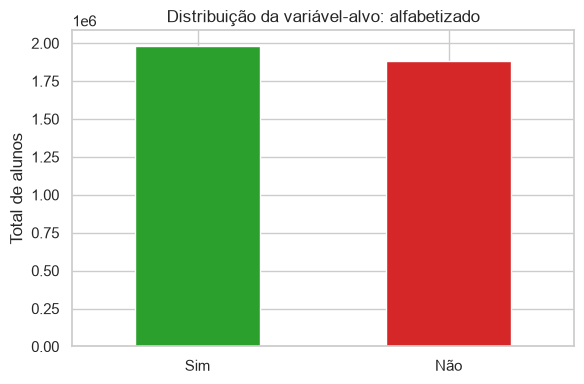

In [4]:
contagem = df["alfabetizado"].value_counts()
percentual = df["alfabetizado"].value_counts(normalize=True) * 100

print(contagem)
print(percentual.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
contagem.plot(kind="bar", color=["#2ca02c", "#d62728"], ax=ax)
ax.set_title("Distribuição da variável-alvo: alfabetizado")
ax.set_xlabel("")
ax.set_ylabel("Total de alunos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/eda_distribuicao_alvo.png", dpi=150)
plt.show()

**Hipótese H1:** a classe está razoavelmente balanceada (~50/52% "Sim"),
o que significa que métricas simples como acurácia já são minimamente
confiáveis, sem precisar de técnicas de balanceamento (SMOTE, class_weight).

## 3. Variáveis categóricas vs. alfabetização

In [5]:
categoricas = ["rede", "presenca", "preenchimento_caderno", "sigla_uf"]

for col in categoricas[:3]:
    tabela = pd.crosstab(df_amostra[col], df_amostra["alfabetizado"], normalize="index") * 100
    print(f"\n--- {col} ---")
    print(tabela.round(1))


--- rede ---
alfabetizado    Não   Sim
rede                     
Estadual       47.0  53.0
Municipal      49.0  51.0
Privada       100.0   0.0

--- presenca ---
alfabetizado    Não   Sim
presenca                 
Ausente       100.0   0.0
Presente       41.0  59.0

--- preenchimento_caderno ---
alfabetizado             Não   Sim
preenchimento_caderno             
Prova não preenchida   100.0   0.0
Prova preenchida        40.9  59.1


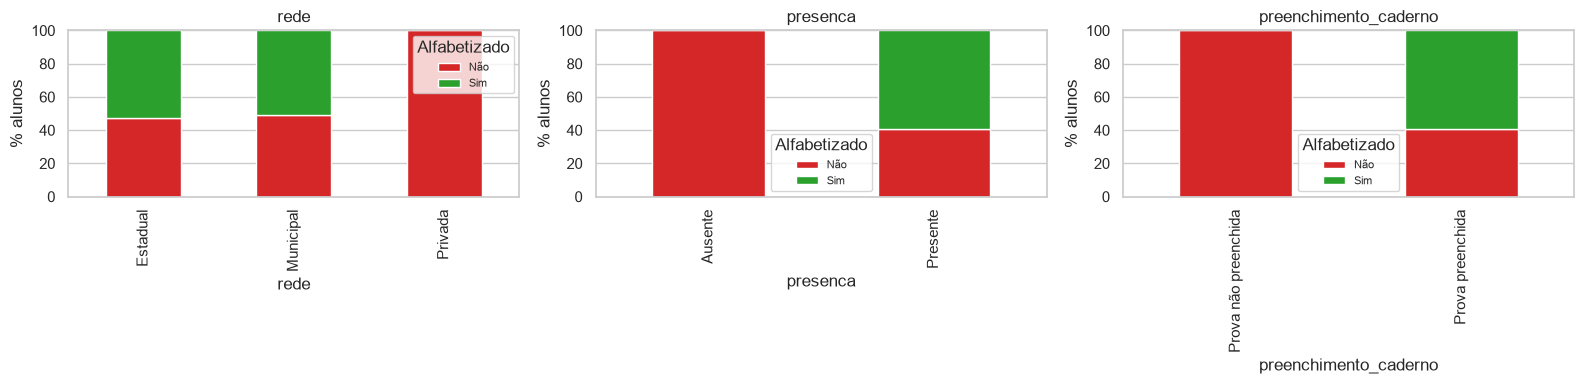

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["rede", "presenca", "preenchimento_caderno"]):
    tabela = pd.crosstab(df_amostra[col], df_amostra["alfabetizado"], normalize="index") * 100
    tabela.plot(kind="bar", stacked=True, ax=ax, color=["#d62728", "#2ca02c"])
    ax.set_title(col)
    ax.set_ylabel("% alunos")
    ax.legend(title="Alfabetizado", fontsize=8)
plt.tight_layout()
plt.savefig("../images/eda_categoricas.png", dpi=150)
plt.show()

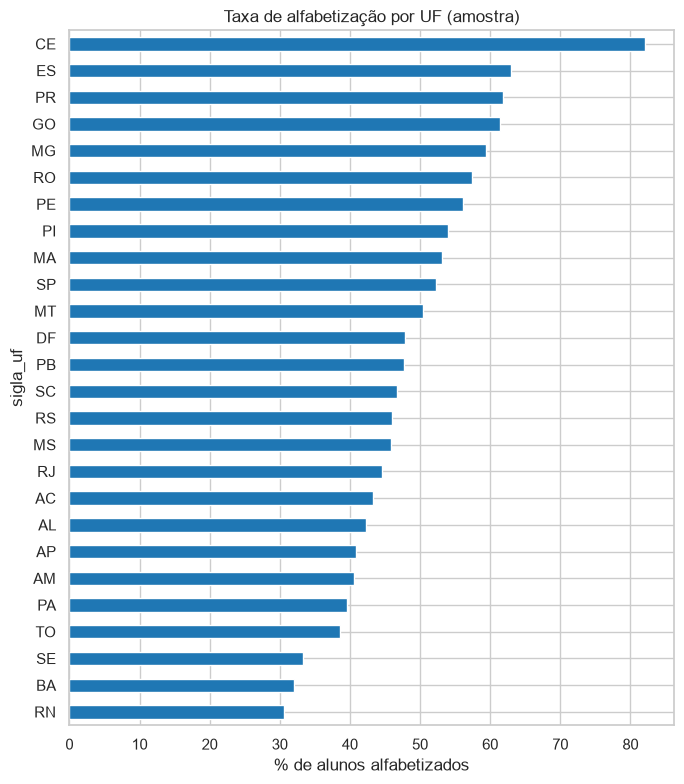

In [7]:
# UF tem muitas categorias — melhor como ranking horizontal
taxa_por_uf = (
    df_amostra.groupby("sigla_uf", observed=True)["alfabetizado"]
    .apply(lambda s: (s == "Sim").mean() * 100)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 8))
taxa_por_uf.plot(kind="barh", ax=ax, color="#1f77b4")
ax.set_xlabel("% de alunos alfabetizados")
ax.set_title("Taxa de alfabetização por UF (amostra)")
plt.tight_layout()
plt.savefig("../images/eda_taxa_por_uf.png", dpi=150)
plt.show()

**Hipótese H2:** existe variação relevante entre UFs na taxa de alfabetização —
justifica manter `sigla_uf` como feature categórica no modelo (dado territorial).

## 4. Variáveis numéricas (metas) vs. alfabetização

Todas as variáveis numéricas do dataset são metas de política pública
(não são resultados realizados — já removemos essas por vazamento de dados).
A pergunta aqui é: municípios/UFs com metas mais ambiciosas têm, de fato,
mais alunos alfabetizados?

In [8]:
numericas = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c]) and c != "ano"]

resumo = df_amostra.groupby("alfabetizado")[numericas].mean().round(2).T
resumo["diferenca"] = (resumo["Sim"] - resumo["Não"]).round(2)
resumo.sort_values("diferenca", key=abs, ascending=False)

alfabetizado,Não,Sim,diferenca
meta_alfabetizacao_2024_municipio,56.39,63.19,6.80
meta_alfabetizacao_2025_municipio,60.61,66.27,5.66
meta_alfabetizacao_2026_municipio,65.01,69.38,4.37
meta_alfabetizacao_2024_uf,58.56,62.20,3.64
meta_alfabetizacao_2025_uf,62.62,65.55,2.93
meta_alfabetizacao_2026_uf,66.58,68.83,2.25
meta_alfabetizacao_2030_municipio,80.00,80.00,0.00
meta_alfabetizacao_2030_uf,80.00,80.00,0.00


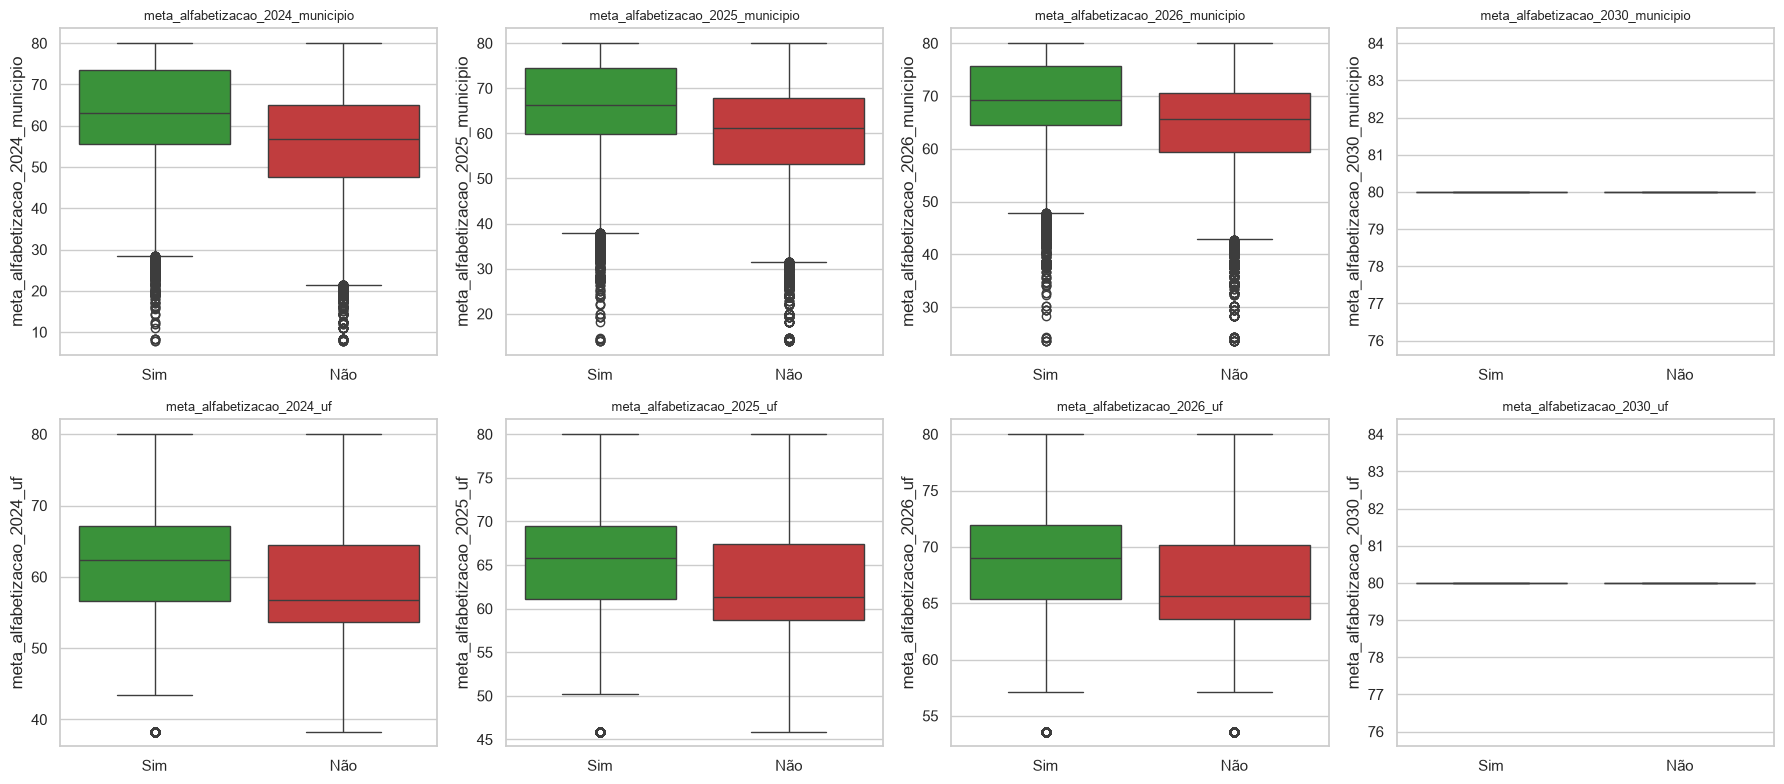

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), numericas):
    sns.boxplot(data=df_amostra, x="alfabetizado", y=col, ax=ax,
                hue="alfabetizado", palette={"Sim": "#2ca02c", "Não": "#d62728"},
                legend=False)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
plt.tight_layout()
plt.savefig("../images/eda_boxplots_metas.png", dpi=150)
plt.show()

## 5. Correlação entre as variáveis numéricas

Como várias metas (2024, 2025, 2026, 2030) tendem a ser correlacionadas entre si
(são a mesma trajetória de política pública), vale checar redundância — isso
justifica por que o Feature Selection não foi crítico aqui: o modelo já lida
bem com colinearidade entre metas via regularização (Regressão Logística) ou
divisão de árvores (Random Forest).

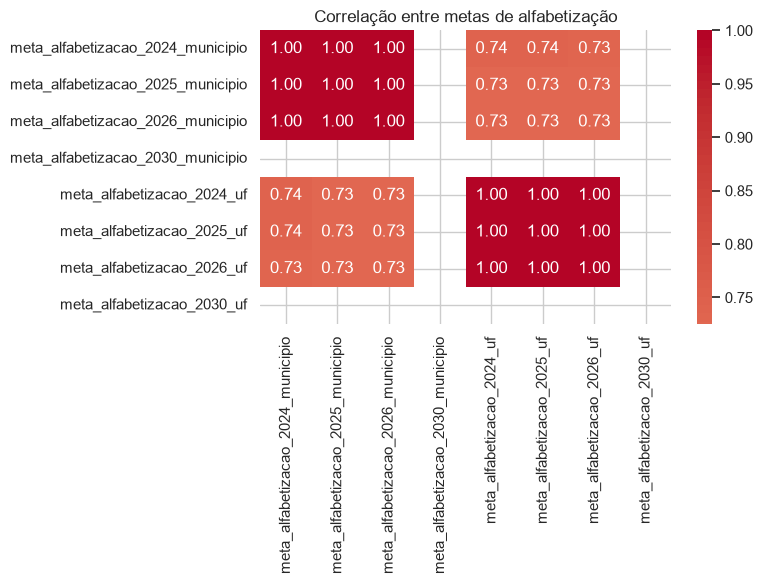

In [11]:
matriz_corr = df_amostra[numericas].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlação entre metas de alfabetização")
plt.tight_layout()
plt.savefig("../images/eda_correlacao.png", dpi=150)
plt.show()

## 6. Síntese — hipóteses que orientam a modelagem

1. **Classes balanceadas** (~50/52%) → não foi necessário balanceamento artificial.
2. **`sigla_uf` tem poder discriminativo** → mantido como feature categórica.
3. **Metas municipais e estaduais são fortemente correlacionadas entre si**
   → esperado; o modelo pode "escolher" quais pesar mais, sem prejuízo.
4. **`rede`, `presenca` e `preenchimento_caderno` mostram diferença visível**
   entre as classes → mantidas como features categóricas.
5. Nenhuma variável de resultado realizado (`proficiencia`, `taxa_alfabetizacao`)
   foi incluída — tratamento de vazamento de dados aplicado na etapa de
   construção do dataset (`build_dataset.py`).

## 7. Correção de escopo — removendo alunos não avaliados

**Achado (seção 3):** `presenca = "Ausente"` e `preenchimento_caderno = "Prova não
preenchida"` aparecem como 100% "Não alfabetizado" — não porque o aluno foi avaliado
e não atingiu o corte, mas porque ele nunca teve `proficiencia` medida. Manter esses
registros faria o modelo aprender a prever "o aluno fez a prova?" em vez de
"o aluno está alfabetizado?".

**Decisão:** o `build_dataset.py` foi ajustado para filtrar a população de modelagem
apenas a alunos com `presenca = "Presente"` e `preenchimento_caderno = "Prova
preenchida"` — os únicos para quem o rótulo "alfabetizado" tem significado real.
As colunas `meta_alfabetizacao_2030_*` também foram removidas por variância zero
(achado da seção 5, heatmap de correlação).

A célula abaixo recarrega o dataset já corrigido e reproduz as mesmas checagens
das seções 2 e 3, para confirmar que o problema foi resolvido.

In [13]:
df_v2 = pd.read_parquet("../data/dataset_ml_alunos.parquet")

print(f"Antes do filtro: {len(df):,} registros")
print(f"Depois do filtro: {len(df_v2):,} registros")
print(f"Removidos: {len(df) - len(df_v2):,} ({(len(df) - len(df_v2)) / len(df) * 100:.1f}%)")
print(f"\nColunas removidas: {set(df.columns) - set(df_v2.columns)}")

Antes do filtro: 3,867,589 registros
Depois do filtro: 3,354,661 registros
Removidos: 512,928 (13.3%)

Colunas removidas: {'meta_alfabetizacao_2030_uf', 'meta_alfabetizacao_2030_municipio', 'presenca', 'preenchimento_caderno'}


In [14]:
# Confirma que a distribuição do alvo continua saudável após o filtro
contagem_v2 = df_v2["alfabetizado"].value_counts(normalize=True) * 100
print("Distribuição do alvo (apos filtro):")
print(contagem_v2.round(2))

Distribuição do alvo (apos filtro):
alfabetizado
Sim    59.16
Não    40.84
Name: proportion, dtype: float64


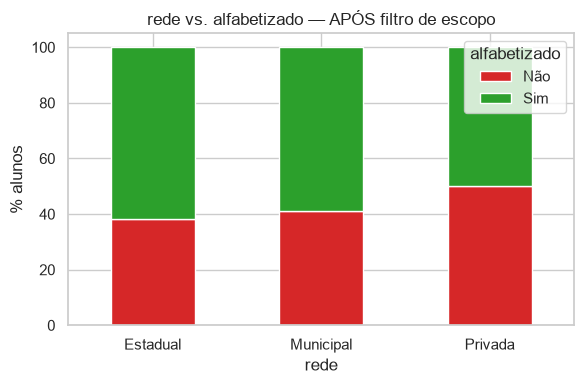

alfabetizado   Não   Sim
rede                    
Estadual      38.1  61.9
Municipal     41.1  58.9
Privada       50.0  50.0


In [15]:
# Confirma que 'rede' não está mais artificialmente distorcida por
# registros sem avaliação (a Privada, em especial, deve mudar de comportamento)
df_v2_amostra = df_v2.sample(n=min(300_000, len(df_v2)), random_state=42)

fig, ax = plt.subplots(figsize=(6, 4))
tabela = pd.crosstab(df_v2_amostra["rede"], df_v2_amostra["alfabetizado"], normalize="index") * 100
tabela.plot(kind="bar", stacked=True, ax=ax, color=["#d62728", "#2ca02c"])
ax.set_title("rede vs. alfabetizado — APÓS filtro de escopo")
ax.set_ylabel("% alunos")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/eda_categoricas_pos_filtro.png", dpi=150)
plt.show()

print(tabela.round(1))

**Conclusão:** com o filtro aplicado, `rede` passa a refletir diferença real de
desempenho entre redes de ensino, sem o artefato de 100%/0% causado por alunos
não avaliados. Esse é o dataset usado na modelagem final (seção "Treinamento e
Validação" do README).